# Lab 4: Classification and Evaluation in NLP

**Name:** Danyal Salman Alhashem  
**ID:** 2240002713


# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

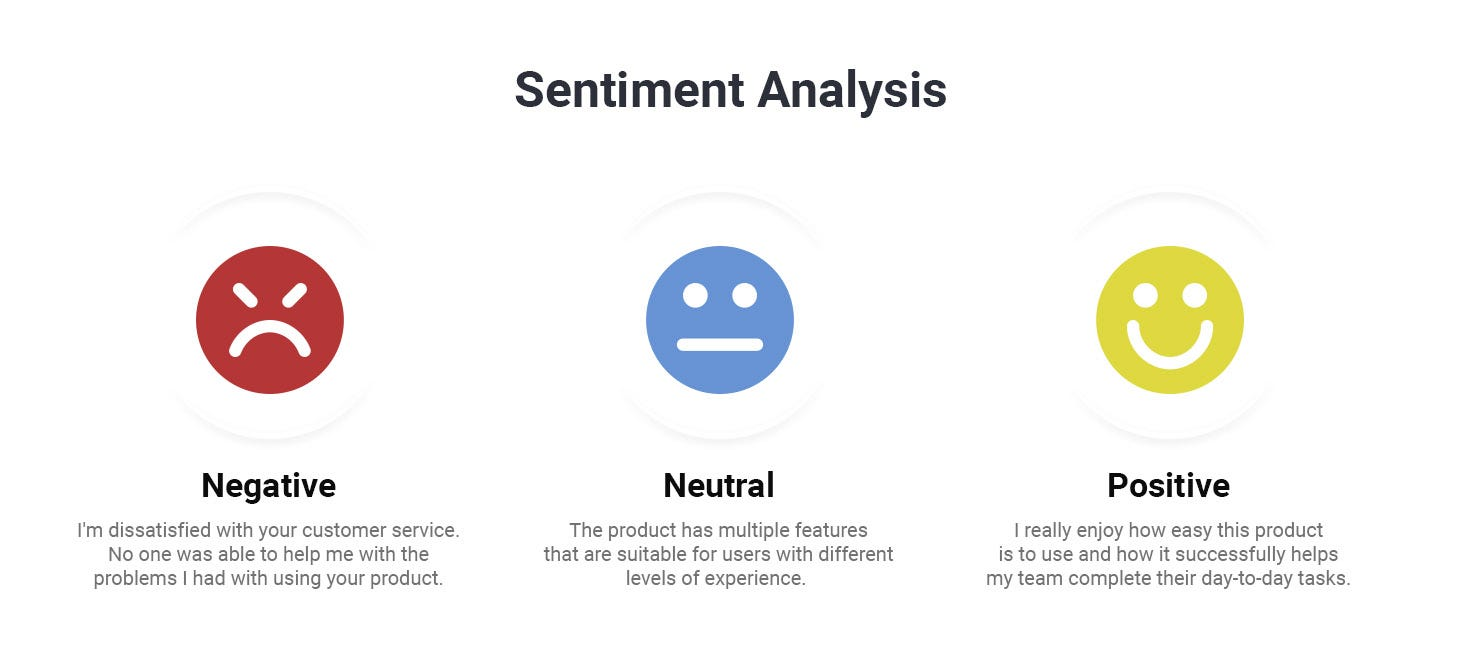

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv(r"C:\Users\danya\Downloads\DisneylandReviews.csv", encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [2]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [3]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [4]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [5]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [7]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

---
## Solution: Amazon Unlocked Mobile Reviews

**Name:** Danyal Salman Alhashem &nbsp;|&nbsp; **ID:** 2240002713

We build a 3-class sentiment classifier (positive / negative / neutral) on the Amazon reviews of unlocked mobile phones, using TF-IDF features and a Naive Bayes classifier.

In [9]:
# ============================================================
# Task 1: Load the data and apply 5 preprocessing steps
# Name: Danyal Salman Alhashem   |   ID: 2240002713
# ============================================================
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# stopwords resource (needed for preprocessing step 5)
nltk.download('stopwords')

# Load the dataset from your computer
data = pd.read_csv(r"C:\Users\danya\Downloads\Amazon_Unlocked_Mobile.csv", encoding='latin-1')

print('Original shape:', data.shape)
data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original shape: (413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [10]:
# (Optional) use a random sample to keep training fast on this large dataset.
# Comment this line out to use the full dataset.
data = data.sample(n=50000, random_state=42) if len(data) > 50000 else data

# --- Preprocessing step 1: drop rows with missing 'Reviews' or 'Rating' ---
data = data.dropna(subset=['Reviews', 'Rating'])

# --- Preprocessing step 2: map star ratings to sentiment classes ---
#   Rating > 3 -> positive, Rating < 3 -> negative, Rating == 3 -> neutral
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))

# Prepare the stopword list (used in step 5)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text)
    # --- Preprocessing step 3: convert to lowercase ---
    text = text.lower()
    # --- Preprocessing step 4: remove punctuation, numbers and special characters ---
    text = re.sub(r'[^a-z\s]', '', text)
    # --- Preprocessing step 5: tokenize and remove stopwords ---
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

# Apply the text cleaning to every review
data['Clean_Review'] = data['Reviews'].apply(preprocess_text)

# Drop reviews that became empty after cleaning
data = data[data['Clean_Review'].str.strip() != '']

print('Shape after preprocessing:', data.shape)
print(data['Sentiment'].value_counts())
data[['Reviews', 'Clean_Review', 'Sentiment']].head()

Shape after preprocessing: (49863, 8)
Sentiment
positive    34186
negative    11830
neutral      3847
Name: count, dtype: int64


,Reviews,Clean_Review,Sentiment
54870,Defective phone. Works only for two days. Phon...,defective phone works two days phone flickerin...,negative
188521,Cool,cool,neutral
137548,Beautiful and excellent quality,beautiful excellent quality,positive
24906,Gave 3 stars because it did not come with a ch...,gave stars come charger box battery already ha...,negative
131601,High resolution camera so you can zoom in afte...,high resolution camera zoom picture taken prin...,negative


In [11]:
# ============================================================
# Task 2: Proper train / test split
# ============================================================
from sklearn.model_selection import train_test_split

X = data['Clean_Review']
y = data['Sentiment']

# 80% training, 20% testing. stratify=y keeps the class balance in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Training size:', X_train.shape)
print('Testing size :', X_test.shape)

Training size: (39890,)
Testing size : (9973,)


In [12]:
# ============================================================
# Task 3: Feature extraction using TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# Limit vocabulary to the 5000 most informative tokens
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit ONLY on training data, then transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('TF-IDF training matrix shape:', X_train_tfidf.shape)
print('TF-IDF testing matrix shape :', X_test_tfidf.shape)

TF-IDF training matrix shape: (39890, 5000)
TF-IDF testing matrix shape : (9973, 5000)


In [13]:
# ============================================================
# Task 4: Train a Naive Bayes classifier
# ============================================================
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

print('Naive Bayes model trained.')

Naive Bayes model trained.


In [14]:
# ============================================================
# Task 5: Evaluate the model on the test set
# ============================================================
from sklearn.metrics import accuracy_score, classification_report

predictions = nb_classifier.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(y_test, predictions))

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.71      0.75      2366
     neutral       0.34      0.02      0.04       769
    positive       0.85      0.97      0.91      6838

    accuracy                           0.84      9973
   macro avg       0.66      0.57      0.56      9973
weighted avg       0.80      0.84      0.80      9973



Confusion Matrix:
 [[1671    5  690]
 [ 242   15  512]
 [ 166   24 6648]]


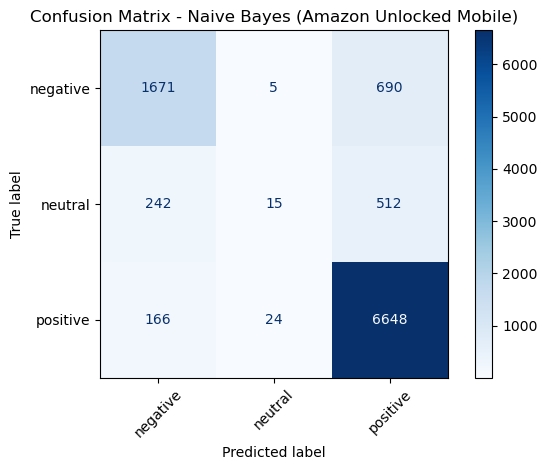

In [15]:
# ============================================================
# Task 6: Confusion matrix
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, predictions, labels=labels)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Naive Bayes (Amazon Unlocked Mobile)')
plt.tight_layout()
plt.show()

---
## What I Learned from This Lab

- **Text classification workflow:** I learned the full NLP pipeline for sentiment analysis — from raw text all the way to an evaluated model.
- **Text preprocessing:** How to clean review text (lowercasing, removing punctuation/numbers, tokenizing, and removing stopwords) and why clean input directly improves the quality of the features.
- **Labeling from ratings:** How to turn star ratings into sentiment classes (positive / negative / neutral).
- **Train/test split:** The importance of splitting data properly and using `stratify` to keep the same class balance in both the training and testing sets.
- **Feature extraction with TF-IDF:** How TF-IDF converts text into numeric vectors, why we fit the vectorizer on the training data only and just transform the test data, and how `max_features` limits the vocabulary.
- **Naive Bayes classifier:** How to train a `MultinomialNB` model, which works well with TF-IDF text features and is fast even on large datasets.
- **Model evaluation:** How to read accuracy, precision, recall, and F1-score from the classification report, and how imbalanced classes (e.g. fewer neutral reviews) affect the results.
- **Confusion matrix:** How to build and read a confusion matrix to see exactly which classes the model confuses with each other, not just the overall accuracy.
